# 02_01 - OMIP Energy Market: Exploratory Data Analysis (EDA)
## 1. Business Context and Resilience Strategy

In the context of the course *42578 Advanced Business Analytics*, this notebook conducts an Exploratory Data Analysis (EDA) on the Iberian Energy Market (OMIP/OMIE) dataset spanning from 2020. 

Rather than merely describing statistical distributions, this EDA is strictly aligned with our project's core theme: **Intelligent Methods for Resilience**. Our factory operates under a **Dual-Action Resilience Strategy**:

1.  **The Financial Shield (Hedging):** Mitigating long-term macro-economic shocks by purchasing Forward Contracts (Futures).
2.  **The Operational Shield (Demand Response):** Mitigating short-term volatility spikes (often driven by weather or grid constraints) by halting or modulating factory production.

This analysis aims to empirically validate the necessity of both shields by exploring market liquidity, regime shifts (Contango vs. Backwardation), and extreme volatility events.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set professional plotting style suitable for academic reports
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 150, 'axes.titlesize': 14, 'axes.labelsize': 12})

# Load the raw extracted dataset
data_path = Path("C:\\Users\\Alejandro\\GitHub\\Data-Driven-Strategies-for-Financial-Resilience-in-Energy-Procurement\\data\\raw\\omip\\omip_prices_raw.csv")
df = pd.read_csv(data_path)

# Parse dates and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Dataset successfully loaded. Dimensions: {df.shape[0]} days x {df.shape[1]} features.")

Dataset successfully loaded. Dimensions: 2192 days x 14 features.


## 2. Market Liquidity Audit (Open Interest)

Before modeling, we must understand the feasibility of executing our *Financial Shield*. Open Interest (OI) measures the total number of outstanding derivative contracts. If a future horizon is illiquid (OI $\approx 0$), the factory cannot realistically buy contracts to hedge risk, and the price signals become statistical noise.

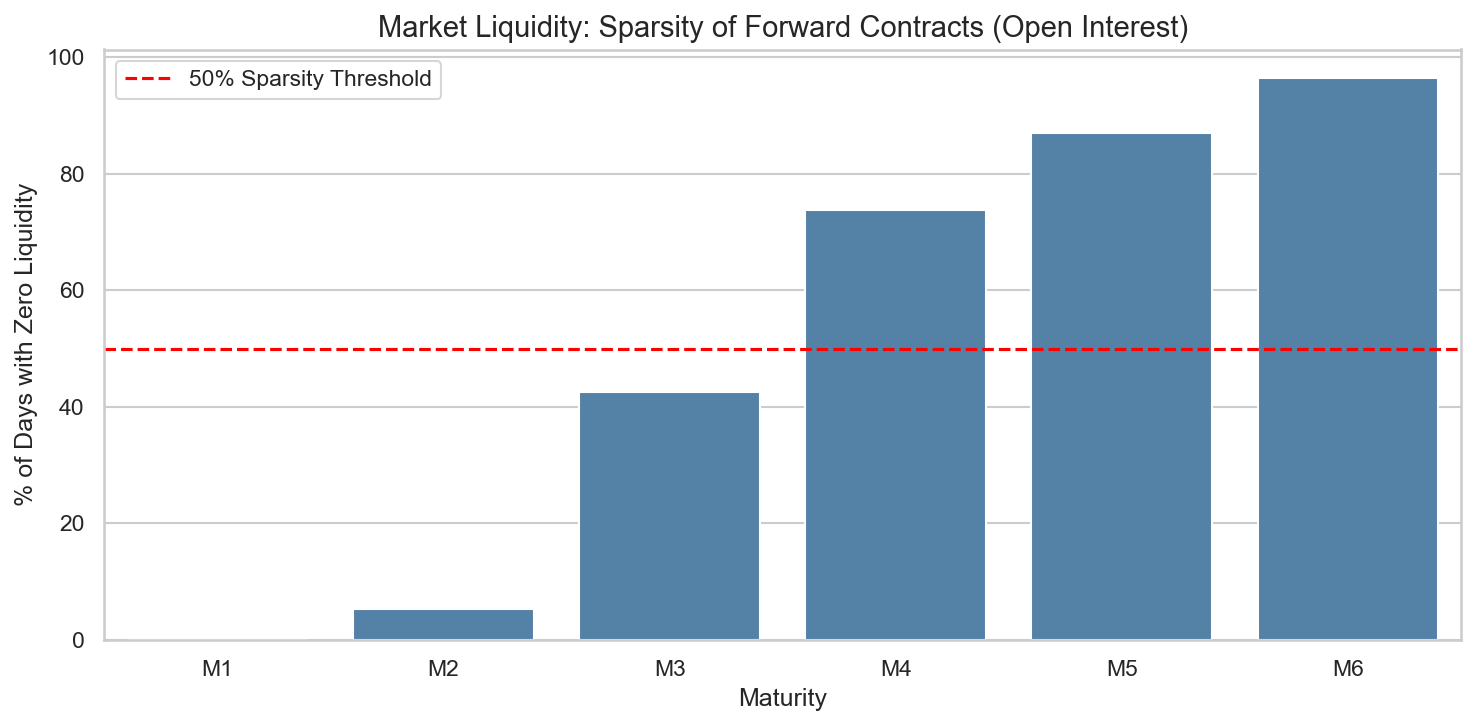

,Maturity,Median_Contracts,Max_Contracts,Sparsity (%)
0,M1,434.0,1724.0,0.05
1,M2,32.0,1552.0,5.38
2,M3,2.0,1395.0,42.56
3,M4,0.0,54.0,73.81
4,M5,0.0,13.0,86.95
5,M6,0.0,3.0,96.53


In [3]:
# Extract Open Interest columns
oi_cols = [col for col in df.columns if 'OpenInterest' in col]

audit_data = []
for col in oi_cols:
    # Calculate the percentage of days where no contracts are open (or data is missing)
    sparsity = ((df[col].isna()) | (df[col] == 0)).mean() * 100
    audit_data.append({
        'Maturity': col.split('_')[1],
        'Median_Contracts': df[col].median(),
        'Max_Contracts': df[col].max(),
        'Sparsity (%)': round(sparsity, 2)
    })

audit_df = pd.DataFrame(audit_data)

# Visualize Liquidity Drop-off
plt.figure(figsize=(10, 5))
sns.barplot(data=audit_df, x='Maturity', y='Sparsity (%)', color='steelblue')
plt.axhline(y=50, color='red', linestyle='--', label='50% Sparsity Threshold')
plt.title('Market Liquidity: Sparsity of Forward Contracts (Open Interest)')
plt.ylabel('% of Days with Zero Liquidity')
plt.legend()
plt.tight_layout()
plt.show()

display(audit_df)

**Business Conclusion from Liquidity:** The M+1 to M+3 horizons possess sufficient liquidity for active hedging. However, M+4 to M+6 exhibit near 100% sparsity. Consequently, our downstream modeling will prune these distant horizons to avoid the "Garbage In, Garbage Out" paradigm.

## 3. The Financial Shield: Market Regimes & Spreads

The foundation of our financial hedging strategy is the price differential (Spread) between the Spot price and the Front-Month Future ($M+1$). 
* **Contango (Future > Spot):** The market expects prices to rise. A normal state where the factory pays a premium for certainty.
* **Backwardation (Future < Spot):** An inverted market indicating a severe, immediate supply shortage (panic). 

Visualizing these regimes justifies why the Reinforcement Learning agent needs the "Spread" feature to decide when to buy futures.

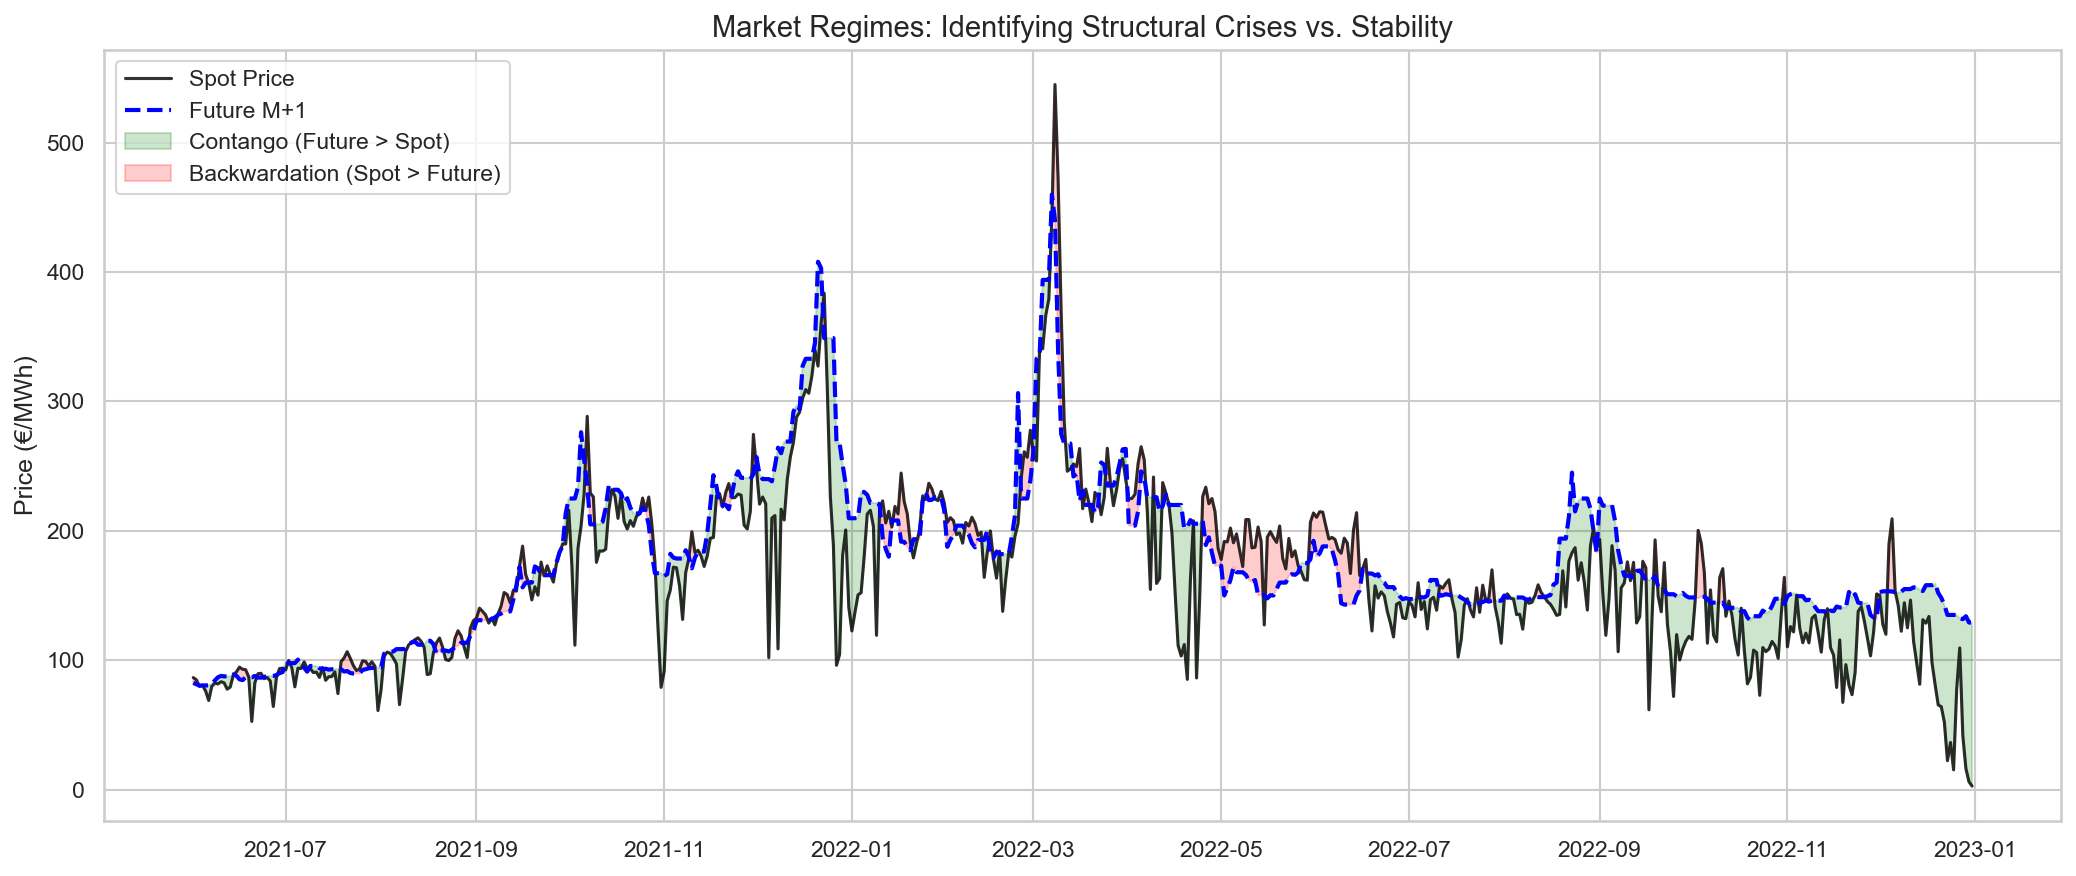

In [10]:
# Focus on a highly volatile period (e.g., the 2021-2022 Energy Crisis)
df_plot = df[(df['Date'] >= '2021-06-01') & (df['Date'] <= '2022-12-31')].copy()

# Forward fill M+1 Future to simulate Friday's price holding over the weekend
df_plot['Future_M1_Price'] = df_plot['Future_M1_Price'].ffill()

plt.figure(figsize=(14, 6))
plt.plot(df_plot['Date'], df_plot['Spot_Price_SPEL'], label='Spot Price', color='black', alpha=0.8, linewidth=1.5)
plt.plot(df_plot['Date'], df_plot['Future_M1_Price'], label='Future M+1', color='blue', linestyle='--', linewidth=2)

# Fill Contango (Stable Expectation)
plt.fill_between(df_plot['Date'], df_plot['Future_M1_Price'], df_plot['Spot_Price_SPEL'], 
                 where=(df_plot['Future_M1_Price'] >= df_plot['Spot_Price_SPEL']), 
                 interpolate=True, color='green', alpha=0.2, label='Contango (Future > Spot)')

# Fill Backwardation (Immediate Crisis)
plt.fill_between(df_plot['Date'], df_plot['Future_M1_Price'], df_plot['Spot_Price_SPEL'], 
                 where=(df_plot['Future_M1_Price'] < df_plot['Spot_Price_SPEL']), 
                 interpolate=True, color='red', alpha=0.2, label='Backwardation (Spot > Future)')

plt.title('Market Regimes: Identifying Structural Crises vs. Stability')
plt.ylabel('Price (€/MWh)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 4. The Operational Shield: Spot Volatility

While the Financial Shield protects against structural regime shifts (the red zones above), the factory also faces short-term, violent price spikes. Since our factory can modulate production, we can execute **Demand Response**—shutting down on days when the Spot price becomes unsustainably high.

To trigger this operational shield, the model needs to understand *Volatility* (risk), not just absolute prices. We visualize how a rolling Standard Deviation captures these sudden market shocks.

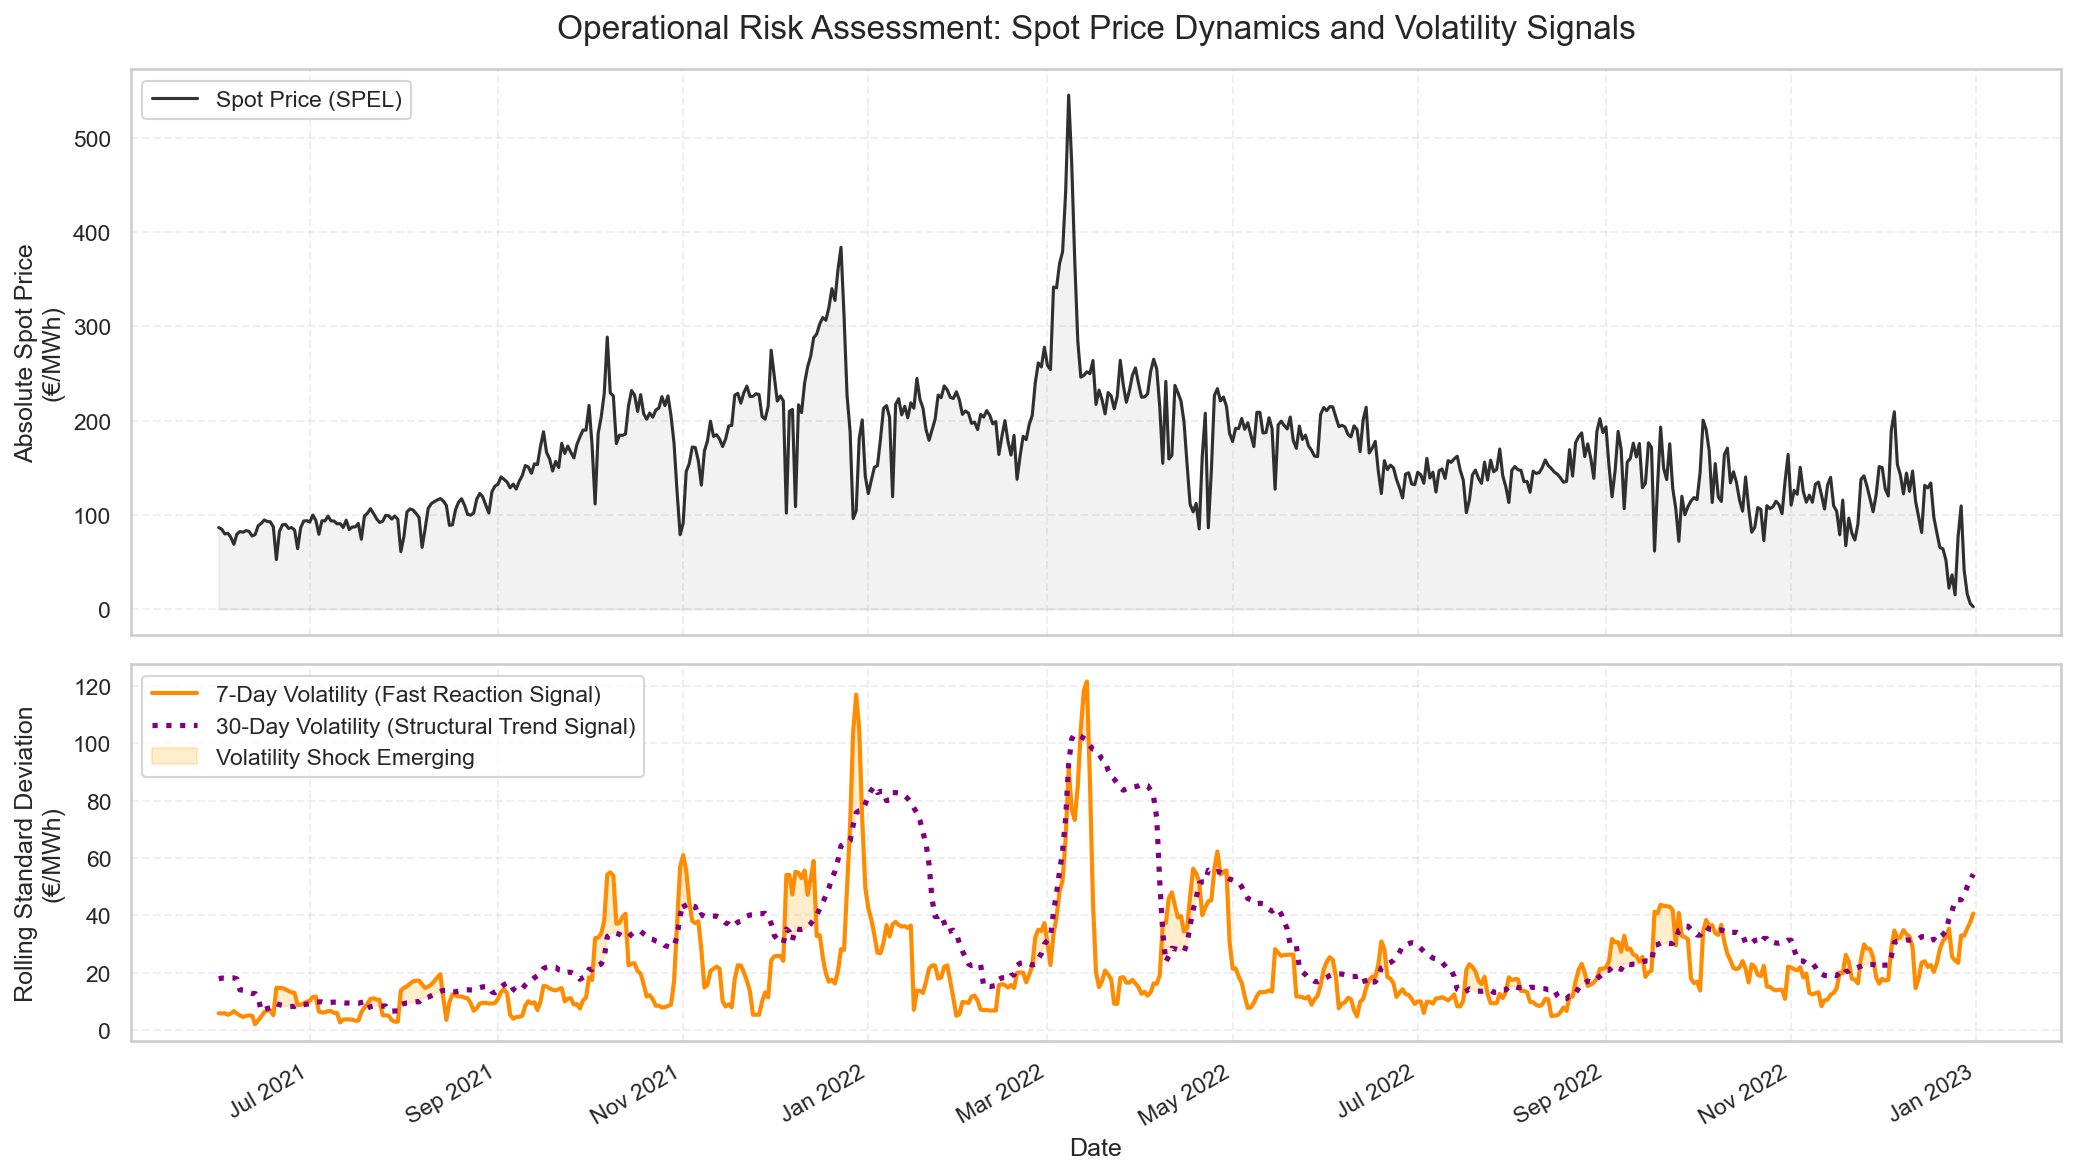

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Asegurarse de que el Date es datetime (si no lo era ya)
df['Date'] = pd.to_datetime(df['Date'])

# Calcular ventanas de volatilidad (si no estaban calculadas)
df['Spot_Vol_7d'] = df['Spot_Price_SPEL'].rolling(window=7, min_periods=1).std()
df['Spot_Vol_30d'] = df['Spot_Price_SPEL'].rolling(window=30, min_periods=1).std()

# Filtrar periodo de crisis
df_vol_plot = df[(df['Date'] >= '2021-06-01') & (df['Date'] <= '2022-12-31')]

# Crear una figura con 2 subplots verticales que comparten el eje X (sharex=True)
# Ajustar ratios: El gráfico de precio es ligeramente más grande que el de volatilidad (height_ratios)
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 2]})

# --- PANEL SUPERIOR: PRECIO ABSOLUTO ---
ax1.plot(df_vol_plot['Date'], df_vol_plot['Spot_Price_SPEL'], color='black', alpha=0.8, linewidth=1.5, label='Spot Price (SPEL)')
ax1.set_title('Operational Risk Assessment: Spot Price Dynamics and Volatility Signals', fontsize=16, pad=15)
ax1.set_ylabel('Absolute Spot Price\n(€/MWh)', fontsize=12)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')

# Rellenar sutilmente el área bajo la curva del precio para dar sensación de volumen/gravedad
ax1.fill_between(df_vol_plot['Date'], df_vol_plot['Spot_Price_SPEL'], alpha=0.1, color='gray')


# --- PANEL INFERIOR: VOLATILIDAD (SEÑAL DE RIESGO) ---
ax2.plot(df_vol_plot['Date'], df_vol_plot['Spot_Vol_7d'], color='darkorange', linewidth=2, label='7-Day Volatility (Fast Reaction Signal)')
ax2.plot(df_vol_plot['Date'], df_vol_plot['Spot_Vol_30d'], color='purple', linewidth=2.5, linestyle=':', label='30-Day Volatility (Structural Trend Signal)')

# Sombrear zonas de "Peligro" donde la volatilidad rápida supera a la estructural (inicio de un shock)
ax2.fill_between(df_vol_plot['Date'], df_vol_plot['Spot_Vol_7d'], df_vol_plot['Spot_Vol_30d'], 
                 where=(df_vol_plot['Spot_Vol_7d'] > df_vol_plot['Spot_Vol_30d']), 
                 interpolate=True, color='orange', alpha=0.2, label='Volatility Shock Emerging')

ax2.set_ylabel('Rolling Standard Deviation\n(€/MWh)', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')

# --- FORMATO FINAL ---
# Mejorar la lectura de las fechas en el eje X
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate() # Rota las fechas para que no se pisen

plt.tight_layout()
plt.show()